# Final Project: Personal Finance Dashboard

---

You have spent the entire semester working with this dataset. You have explored it, cleaned it, summarized it, visualized it, joined it, analyzed it over time, and audited it for quality problems. This project is your chance to put all of that together.

In this notebook, you will build a personal finance summary — the kind of analysis a budgeting app might show you — using the cleaned semester transactions dataset.

**You will:**
- Load and prepare the cleaned dataset
- Compute ending balances for each account, starting from realistic opening balances
- Analyze total spending three ways: by payment method, by category, and by merchant
- Identify opportunities to cut costs and write a short budget recommendation
- Simulate 401(k) growth using compounding returns
- Reflect on what you found

**A note on AI tools:**  
You are encouraged to use GitHub Copilot Chat to help you write code in this project. That is a real professional skill. However, you are responsible for every line of code in this notebook. If Copilot suggests something, you need to understand what it does and verify that it produces the correct result. Copilot does not know the quirks of this specific dataset — you do.

---

## New in this notebook: `numpy`

This project introduces one new library: **numpy** (imported as `np`). You will use it in the 401(k) section to generate random numbers. Numpy is one of the foundational Python libraries for numerical computation — pandas itself is built on top of it.

The two numpy functions you need here are:

```python
np.random.seed(42)              # Set the seed so everyone gets the same random numbers
np.random.uniform(low, high)    # Generate one random number between low and high
```

Setting a seed means the random number generator starts from the same position every time. Everyone in the class will produce identical charts even though the numbers appear random.

---

## 0) Setup

Import the libraries you need and load the cleaned dataset.

Make sure `transactions.csv` and the remaining lookup files are in your data directory.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [6]:
# Load the cleaned transactions dataset and the lookup tables into DataFrames. 
# Data files should be in a 'data' subfolder: data/transactions.csv

df = pd.read_csv('data/transactions.csv')
accounts = pd.read_csv('data/accounts.csv')
categories = pd.read_csv('data/categories.csv')
merchants = pd.read_csv('data/merchants.csv')


In [7]:
# Inspect the first few rows and confirm the shape of the DataFrames
print("Transactions DataFrame:")
print(f"Shape: {df.shape}")
print(df.head())

print("\n" + "="*50 + "\n")

print("Accounts DataFrame:")
print(f"Shape: {accounts.shape}")
print(accounts.head())

print("\n" + "="*50 + "\n")

print("Categories DataFrame:")
print(f"Shape: {categories.shape}")
print(categories.head())

print("\n" + "="*50 + "\n")

print("Merchants DataFrame:")
print(f"Shape: {merchants.shape}")
print(merchants.head())

Transactions DataFrame:
Shape: (1378, 9)
  transaction_id        date account_id transaction_type category_id  \
0       T0000001  2022-01-01        CHK           Income         PAY   
1       T0000002  2022-01-01        CHK         Transfer      RET401   
2       T0000003  2022-01-01     INV401         Transfer      RET401   
3       T0000617  2022-01-01        CHK          Expense        GROC   
4       T0000473  2022-01-03        CHK          Expense        PHON   

  merchant_id   amount  payment_method        description  
0   M_PAYROLL  4259.26  Direct Deposit           Paycheck  
1      M_401K  -255.56         Payroll  401k Contribution  
2      M_401K   255.56         Payroll  401k Contribution  
3       M0002   -62.29           Debit          Groceries  
4       M0012   -85.00             ACH               PHON  


Accounts DataFrame:
Shape: (5, 3)
  account_id   account_name account_type
0        CHK       Checking         Bank
1        SAV        Savings         Bank
2      

---

## 1) Prepare the Data

Before you can analyze anything, get the data into a usable shape.

You need to:
1. Parse the `date` column so Python treats it as a real date (not a string)
2. Join the lookup tables so you have names instead of IDs

In [8]:
# 1. Parse date column
df['date'] = pd.to_datetime(df['date'])


# 2. Join the lookup tables to add names
df = df.merge(accounts, on='account_id', how='left', suffixes=('', '_account'))
df = df.merge(categories, on='category_id', how='left', suffixes=('', '_category'))
df = df.merge(merchants, on='merchant_id', how='left', suffixes=('', '_merchant'))

In [16]:
# Verify: confirm date is parsed and name columns are present
print(f"Date column type: {df['date'].dtype}")
print(f"\nAll columns in df:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

Date column type: datetime64[us]

All columns in df:
['transaction_id', 'date', 'account_id', 'transaction_type', 'category_id', 'merchant_id', 'amount', 'payment_method', 'description', 'account_name', 'account_type', 'category_name', 'category_group', 'merchant_name', 'industry', 'city', 'is_online']

First few rows:
  transaction_id       date account_id transaction_type category_id  \
0       T0000001 2022-01-01        CHK           Income         PAY   
1       T0000002 2022-01-01        CHK         Transfer      RET401   
2       T0000003 2022-01-01     INV401         Transfer      RET401   
3       T0000617 2022-01-01        CHK          Expense        GROC   
4       T0000473 2022-01-03        CHK          Expense        PHON   

  merchant_id   amount  payment_method        description account_name  \
0   M_PAYROLL  4259.26  Direct Deposit           Paycheck     Checking   
1      M_401K  -255.56         Payroll  401k Contribution     Checking   
2      M_401K   255.56        

---

## 2) Account Balances

This section computes the ending balance for each account.

### Opening balances

Every account starts somewhere. Use these opening balances:

| Account | Opening Balance | Notes |
|---|---|---|
| CHK | $500.00 | Checking account |
| SAV | $5,000.00 | Emergency fund. A common financial planning guideline is to keep 3–6 months of living expenses in an accessible savings account before investing. This is your safety net. |
| CC1 | $0.00 | No balance carried in |
| CC2 | $0.00 | No balance carried in |
| INV401 | $0.00 | Handled separately in Section 5 |

### How each account works

**Checking (CHK)**  
The hub of this financial picture. Money flows **in** as `Income` (paychecks, bonuses, side income). Money flows **out** as `Expense` (direct bills paid from checking like rent, utilities, groceries) and as `Transfer` (credit card payments and 401k contributions leaving the account). Include all three transaction types when computing the CHK balance.

**Savings (SAV)**  
This account only has interest transactions in the dataset — small income deposits each month. The $5,000 emergency fund grows slowly and steadily.

**Credit Cards (CC1 and CC2)**  
`Expense` transactions are charges (negative — you owe more). `Transfer` transactions are payments received from CHK (positive — balance reduced). The ending balance tells you what is still owed on each card.

> **Think before you code:** Charges increase what you owe, payments reduce it. Make sure the sign of your final credit card balance correctly reflects what is still owed — a negative remaining balance means money is still due.  Zero means you paid it all off. A positive balance would mean you overpaid and are owed money back.

In [10]:
# Checking account (CHK) — compute ending balance
# Include ALL transaction types (Income, Expense, Transfer)
# Start from the opening balance of $500.00

chk_opening = 500.00

chk_ending = chk_opening + df[df['account_id'] == 'CHK']['amount'].sum()
print(f"CHK ending balance: ${chk_ending:,.2f}")

CHK ending balance: $396,138.08


In [11]:
# Savings account (SAV) — compute ending balance
# Start from the opening balance of $5,000.00

sav_opening = 5000.00

sav_ending = sav_opening + df[df['account_id'] == 'SAV']['amount'].sum()
print(f"SAV ending balance: ${sav_ending:,.2f}")

SAV ending balance: $5,599.65


In [12]:
# Credit card accounts (CC1 and CC2) — compute ending balance for each
# Both start at $0.00
# Expenses are charges (negative in dataset), Transfers are payments (positive)

cc1_opening = 0.00
cc2_opening = 0.00

cc1_ending = cc1_opening + df[df['account_id'] == 'CC1']['amount'].sum()
cc2_ending = cc2_opening + df[df['account_id'] == 'CC2']['amount'].sum()

print(f"CC1 ending balance: ${cc1_ending:,.2f}")
print(f"CC2 ending balance: ${cc2_ending:,.2f}")

CC1 ending balance: $4,073.74
CC2 ending balance: $-1,351.72


In [13]:
# Print a clean account summary showing the ending balance for each account
# Format the values as dollar amounts

print("="*50)
print("ACCOUNT BALANCE SUMMARY")
print("="*50)
print(f"CHK (Checking):    ${chk_ending:>12,.2f}")
print(f"SAV (Savings):     ${sav_ending:>12,.2f}")
print(f"CC1 (Credit Card): ${cc1_ending:>12,.2f}")
print(f"CC2 (Credit Card): ${cc2_ending:>12,.2f}")
print("="*50)

ACCOUNT BALANCE SUMMARY
CHK (Checking):    $  396,138.08
SAV (Savings):     $    5,599.65
CC1 (Credit Card): $    4,073.74
CC2 (Credit Card): $   -1,351.72


**What do you notice about the credit card balances?** Write 1–2 sentences.

*Write here.*

One credit card still has money owed and the other is overpaid. It is noticeable that the amount overpaid is much larger than the amount that's still due on the other card. 

---

## 3) Total Spending: Three Views

Now you will analyze where the money went. You will look at spending from three angles — each one answers a different question.

### Before you begin: define "spending"

For all three charts, you want only `Expense` transactions. Exclude `Income` and `Transfer` rows.

Also exclude the `INV401` account — retirement contributions are not consumer spending, and you will analyze that account separately in Section 5.  In this dataset, all `INV401` transactions are `Transfer` type, so filtering for `Expense` will exclude them, but you can also explicitly exclude the account if you want to be sure.

Create a filtered DataFrame called `expenses` that you will reuse across all three charts. Convert the amounts to positive values — expenses are stored as negative numbers in this dataset, and positive values are easier to read in charts.

In [19]:
# Create the expenses DataFrame:
# - Only Expense transaction type
# - Exclude INV401 account
# - Convert amounts to positive values

expenses = df[(df['transaction_type'] == 'Expense') & (df['account_id'] != 'INV401')].copy()
expenses['amount'] = abs(expenses['amount'])

### Chart 1: Spending by Payment Method — Credit Card vs. Checking

**Question:** How much of our total spending went on credit cards vs. paid directly from checking?

Group `expenses` by `account_id` and sum the amounts. CHK is direct checking spending. CC1 and CC2 are credit card spending.

Create a **bar chart** showing total spending by account. Include a title, labeled axes, and dollar formatting on the y-axis.

> **Reminder — dollar formatting on the y-axis:**
> ```python
> ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
> ```

In [20]:
# Summarize spending by account_id
spending_by_account = expenses.groupby('account_id')['amount'].sum().sort_values(ascending=False)
print(spending_by_account)

account_id
CHK    96127.29
CC1    10867.85
CC2     8583.04
Name: amount, dtype: float64


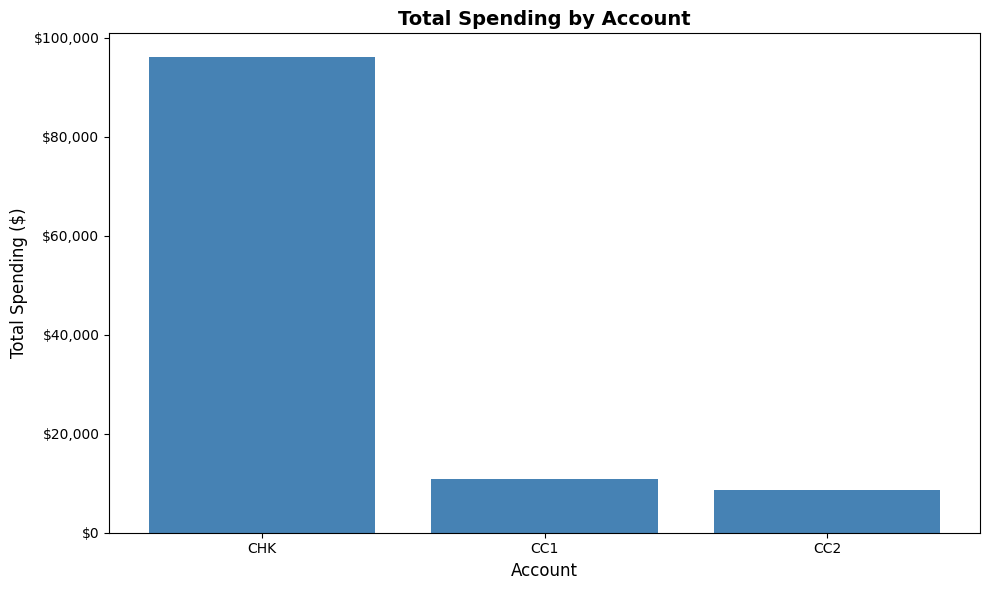

In [21]:
# Bar chart: total spending by account (CHK, CC1, CC2)
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(spending_by_account.index, spending_by_account.values, color='steelblue')

ax.set_title('Total Spending by Account', fontsize=14, fontweight='bold')
ax.set_xlabel('Account', fontsize=12)
ax.set_ylabel('Total Spending ($)', fontsize=12)

# Dollar formatting on y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

**Interpretation (1–2 sentences):** What does this chart tell you about how this person pays for things?

*Write here.*

The person uses checks for a vast majority of thier transactions. 

### Chart 2: Spending by Category — Top 10

**Question:** What are the biggest spending categories across all accounts?

Group `expenses` by `category name` and sum the amounts. Keep only the top 10 by total spend, sorted largest to smallest.

Create a **horizontal bar chart** — category labels are easier to read horizontally than vertically.

Include a title, labeled axes, and dollar formatting on the x-axis.

In [22]:
# Summarize spending by category name, keep top 10
spending_by_category = expenses.groupby('category_name')['amount'].sum().sort_values(ascending=False).head(10)
print(spending_by_category)


category_name
Rent/Mortgage         61140.00
Groceries             15241.34
Insurance              8640.00
Gas/Transportation     8332.20
Utilities              6785.95
Dining Out             6125.06
Phone/Internet         4320.00
Entertainment          3889.63
Subscriptions          1104.00
Name: amount, dtype: float64


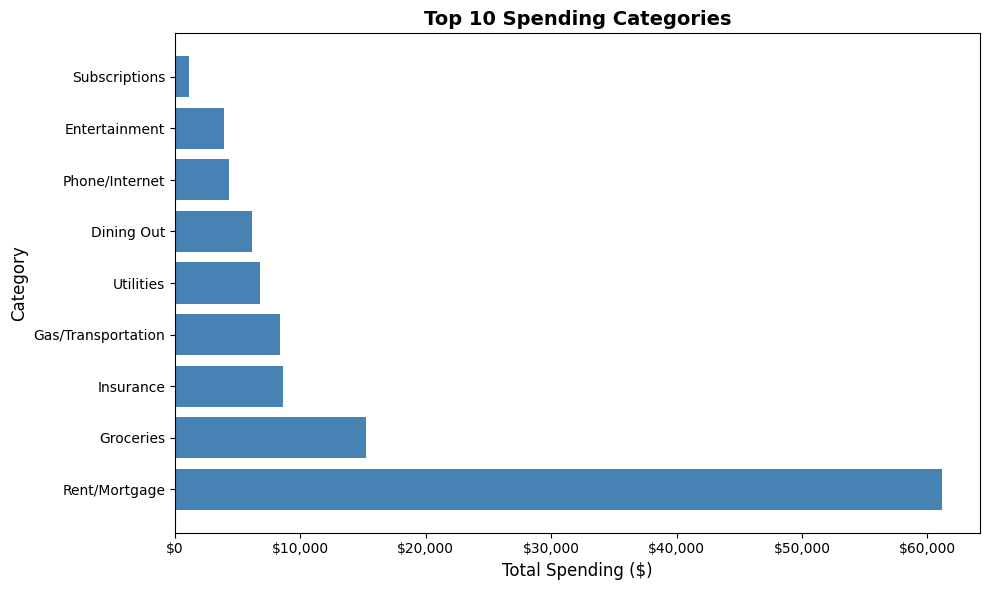

In [23]:
# Horizontal bar chart: top 10 spending categories
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(spending_by_category.index, spending_by_category.values, color='steelblue')

ax.set_title('Top 10 Spending Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Spending ($)', fontsize=12)
ax.set_ylabel('Category', fontsize=12)

# Dollar formatting on x-axis
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

**Interpretation (1–2 sentences):** What stands out to you about the category breakdown?

*Write here.*

What stands out the most is how much more the person pays for their rent/mortgage compared to all other categories.

### Chart 3: Spending by Merchant — Top 10

**Question:** Which specific merchants received the most money?

Group `expenses` by merchant name and sum the amounts. Keep only the top 10.

Create another **horizontal bar chart**.

> **Note:** Make sure your merchant join from Section 1 is complete. If you only have `merchant_id` at this point, go back and finish that join before continuing.

In [24]:
# Summarize spending by merchant name, keep top 10
spending_by_merchant = expenses.groupby('merchant_name')['amount'].sum().sort_values(ascending=False).head(10)
print(spending_by_merchant)

merchant_name
FoxRiver Apartments    61140.00
QuickStop               8872.81
HealthPlus              8640.00
CityPower               6785.95
BrightGas               6460.20
FreshMart               6368.53
BrewHouse               6125.06
GigaNet                 4320.00
CoffeeCo                3889.63
MetroTransit            1872.00
Name: amount, dtype: float64


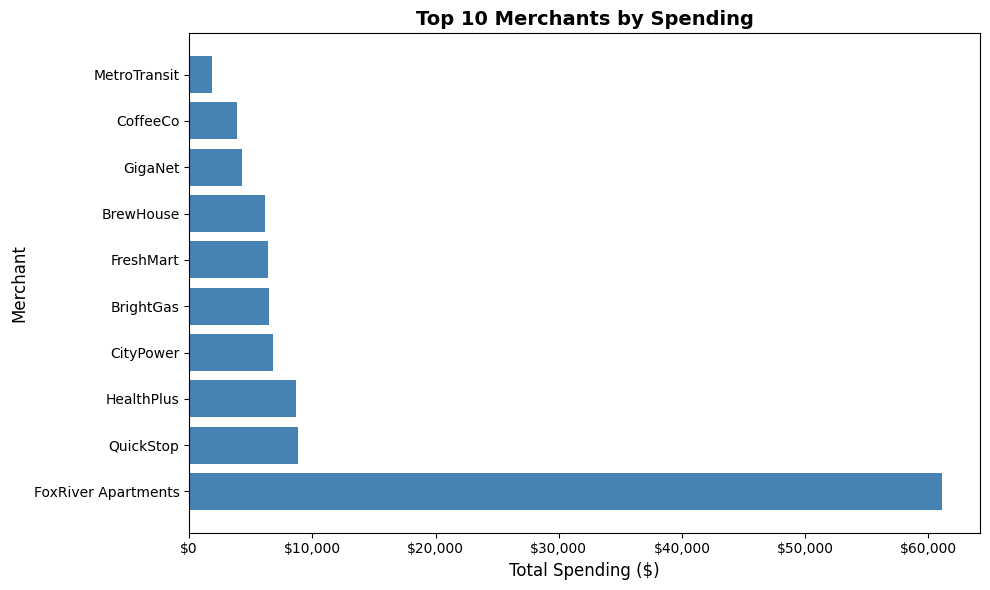

In [25]:
# Horizontal bar chart: top 10 merchants by spending
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(spending_by_merchant.index, spending_by_merchant.values, color='steelblue')

ax.set_title('Top 10 Merchants by Spending', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Spending ($)', fontsize=12)
ax.set_ylabel('Merchant', fontsize=12)

# Dollar formatting on x-axis
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

**Interpretation (1–2 sentences):** Any surprises in the merchant list?

*Write here.*

No, for example it makes sense that FoxRiver Apartments would be so high compared to all of the others because for chart 2 rent was the highest amount by far. 

---

## 4) Budget Analysis

Now that you know where the money went, the next question is: *where could we spend less?*

This is what analysts actually do — not just describe the past, but use data to make recommendations.

### Step 4a — Monthly average spending by category

Compute the **monthly average spending** for each category. Totals are useful, but a monthly average is more practical for budgeting — it tells you what this person spends on a recurring basis.

To get there:
1. Group `expenses` by month (from `date`) and `category name`, and sum the amounts — this gives you total spending per category per month
2. Group that result by `category name` and take the mean — this gives you the average monthly spend per category

> **Hint:** You can do this in two steps with intermediate variables, or chain the groupby operations. Either approach is fine.

In [35]:
# Step 1: total spending per category per month
spending_per_month = expenses.groupby([expenses['date'].dt.to_period('M'), 'category_name'])['amount'].sum().reset_index()
spending_per_month.rename(columns={'date': 'year_month'}, inplace=True)

# Step 2: average monthly spending per category
monthly_avg_by_category = spending_per_month.groupby('category_name')['amount'].mean().sort_values(ascending=False)

In [36]:
# Display monthly averages sorted from highest to lowest, formatted as dollar amounts
for category, amount in monthly_avg_by_category.items():
    print(f"{category:.<30} ${amount:>8,.2f}")

Rent/Mortgage................. $1,273.75
Groceries..................... $  317.53
Insurance..................... $  180.00
Gas/Transportation............ $  173.59
Utilities..................... $  141.37
Dining Out.................... $  130.32
Entertainment................. $   94.87
Phone/Internet................ $   90.00
Subscriptions................. $   23.00


### Step 4b — Budget Recommendation Memo

Look at your monthly averages. Identify **2–3 categories** where spending could reasonably be reduced.

Good candidates are **discretionary** categories — things like dining out, entertainment, or subscriptions — rather than fixed costs like rent, insurance, or utilities that are difficult to change.

For each category:
- State the current monthly average
- Propose a realistic reduced target
- Calculate the monthly savings and the annual savings (monthly × 12)

You may calculate the savings in code below, or do the math directly in your memo — your choice.

In [37]:
# Optional: calculate projected savings in code
# Dining Out savings
dining_current = 130.32
dining_target = 80.00
dining_monthly_savings = dining_current - dining_target
dining_annual_savings = dining_monthly_savings * 12

# Entertainment savings
entertainment_current = 94.87
entertainment_target = 50.00
entertainment_monthly_savings = entertainment_current - entertainment_target
entertainment_annual_savings = entertainment_monthly_savings * 12

# Subscriptions savings
subscriptions_current = 23.00
subscriptions_target = 10.00
subscriptions_monthly_savings = subscriptions_current - subscriptions_target
subscriptions_annual_savings = subscriptions_monthly_savings * 12

total_annual_savings = dining_annual_savings + entertainment_annual_savings + subscriptions_annual_savings

print("BUDGET SAVINGS PROJECTIONS")
print("="*50)
print(f"\nDining Out:")
print(f"  Current:     ${dining_current:>7,.2f}/month")
print(f"  Target:      ${dining_target:>7,.2f}/month")
print(f"  Monthly save: ${dining_monthly_savings:>6,.2f}")
print(f"  Annual save:  ${dining_annual_savings:>6,.2f}")

print(f"\nEntertainment:")
print(f"  Current:     ${entertainment_current:>7,.2f}/month")
print(f"  Target:      ${entertainment_target:>7,.2f}/month")
print(f"  Monthly save: ${entertainment_monthly_savings:>6,.2f}")
print(f"  Annual save:  ${entertainment_annual_savings:>6,.2f}")

print(f"\nSubscriptions:")
print(f"  Current:     ${subscriptions_current:>7,.2f}/month")
print(f"  Target:      ${subscriptions_target:>7,.2f}/month")
print(f"  Monthly save: ${subscriptions_monthly_savings:>6,.2f}")
print(f"  Annual save:  ${subscriptions_annual_savings:>6,.2f}")

print("="*50)
print(f"TOTAL ANNUAL SAVINGS:     ${total_annual_savings:>6,.2f}")
print("="*50)

BUDGET SAVINGS PROJECTIONS

Dining Out:
  Current:     $ 130.32/month
  Target:      $  80.00/month
  Monthly save: $ 50.32
  Annual save:  $603.84

Entertainment:
  Current:     $  94.87/month
  Target:      $  50.00/month
  Monthly save: $ 44.87
  Annual save:  $538.44

Subscriptions:
  Current:     $  23.00/month
  Target:      $  10.00/month
  Monthly save: $ 13.00
  Annual save:  $156.00
TOTAL ANNUAL SAVINGS:     $1,298.28


### Budget Memo

**To:** Account Holder  
**From:** Matthew Waldschmidt  
**Subject:** Spending Reduction Recommendations  

Based on an analysis of transactions from January 2022 through December 2025, I recommend the following budget adjustments:

---

**Category 1: Dining Out**  
Current monthly average: $130.32  
Proposed monthly target: $80.00  
Monthly savings: $50.32  
Annual savings: $603.84  
Rationale: This is a reasonable cut because $80 per month equals out to $20 per week which is either two fast food restaurants or one nice sit down meal. It'll save over $600 per year in the end which is great savings. 

---

**Category 2: Entertainment**  
Current monthly average: $94.87  
Proposed monthly target: $50.00  
Monthly savings: $44.87  
Annual savings: $538.44  
Rationale: This is a reasonable cut because there's a lot of free or low cost entertaminment out there. By cutting your entertaiment spend by almost 50% per month you can save over $500 per year.

---

**Category 3: Subscriptions (optional)**  
Current monthly average: $23.00  
Proposed monthly target: $10.00  
Monthly savings: $13.00  
Annual savings: $156.00  
Rationale: Lastly, this is a reasonable cut because you only need to subscribe to one streaming service at a time and once you finish a show you can cancel and sign up for another one. This will save you over $150 per year. 

---

**Total projected annual savings: $1,298.28**

---

## 5) 401(k) Growth Simulation

The `INV401` account tracks 401(k) contributions — money transferred from each paycheck into a retirement investment account. But contributions are only part of the story. The other part is **investment returns**: the account earns (or occasionally loses) money each month based on market performance.

In this section, you will simulate what that account looks like over time by applying a random monthly return to the growing balance. This is called **compounding** — each month's return is applied to the full balance, including all growth from prior months. The longer money stays invested, the more it compounds. This is why starting to save for retirement early matters so much.

### Assumptions
- Annual return: somewhere between **-2% and +10%** per year, randomized each month
- Monthly rate = annual rate ÷ 12
- Random seed is set to `42` so everyone gets the same result
- Account starts at $0

### How compounding works step by step

At the end of each month:
1. A new contribution arrives from payroll
2. The entire balance — including that new contribution — earns a return for the month

In code, one month looks like this:
```python
balance = (balance + contribution) * (1 + monthly_rate)
```

Repeat this for every month in chronological order and you get the account's full history.

---

### Step 5a — Get monthly 401(k) contributions

The `INV401` account receives contributions from CHK via payroll transfers. These are recorded as positive `Transfer` amounts on the `INV401` account.

Group `INV401` transactions by month using the `date` column and sum to get total contributions per month.

> **This code is provided — read it carefully and run it.**

In [30]:
# Get monthly 401(k) contributions from date-based monthly grouping
inv401 = df[df['account_id'] == 'INV401'].copy()

contributions = (
    inv401
    .groupby(inv401['date'].dt.to_period('M'))['amount']
    .sum()
    .reset_index()
    .rename(columns={'date': 'year_month', 'amount': 'contribution'})
)

print(f"Months with contributions: {len(contributions)}")
print(f"Monthly range: ${contributions['contribution'].min():.2f} — ${contributions['contribution'].max():.2f}")
contributions.head()

Months with contributions: 48
Monthly range: $511.12 — $900.00


,year_month,contribution
0,2022-01,766.68
1,2022-02,511.12
2,2022-03,511.12
3,2022-04,511.12
4,2022-05,511.12


### Step 5b — Simulate the growing balance

Now simulate the account month by month. The loop walks through every month in order, adds the contribution, applies a random return, and records the new balance.

We also track `total_contributed` separately — the cumulative dollars deposited with no growth. This is the baseline for the chart in the next step.

> **This code is provided — read it carefully and run it.**

In [34]:
# Set the random seed — everyone gets the same result
np.random.seed(42)

balance = 0.0
balances = []
cumulative_contributions = []
total_contributed = 0.0

for _, row in contributions.iterrows():
    contribution = row['contribution']

    # Random annual return between -2% and +10%, converted to a monthly rate
    annual_return = np.random.uniform(-0.02, 0.10)
    monthly_rate = annual_return / 12

    # Add contribution then apply the monthly return to the full balance
    balance = (balance + contribution) * (1 + monthly_rate)
    total_contributed += contribution

    balances.append(round(balance, 2))
    cumulative_contributions.append(round(total_contributed, 2))

# Add results to the contributions DataFrame
contributions['account_value'] = balances
contributions['total_contributed'] = cumulative_contributions

# Keep a 'date' column for charting
contributions['date'] = contributions['year_month'].dt.to_timestamp()

# Summary
final_value = contributions['account_value'].iloc[-1]
final_contributed = contributions['total_contributed'].iloc[-1]
print(f"Total contributions made: ${final_contributed:,.2f}")
print(f"Final account value:      ${final_value:,.2f}")
print(f"Growth from returns:      ${final_value - final_contributed:,.2f}")

Total contributions made: $29,400.00
Final account value:      $31,407.41
Growth from returns:      $2,007.41


### Step 5c — Chart: What you put in vs. what it is worth

Create a line chart with **two lines** on the same axes:
- **Total contributed** — cumulative dollars deposited, with no investment growth applied
- **Account value** — actual balance after compounding returns

The gap between the two lines is the value created purely by investment returns. That gap is the whole point of investing for retirement.

Your chart should have:
- A descriptive title
- Labeled axes
- Dollar formatting on the y-axis
- Readable date labels on the x-axis
- A legend identifying each line

> **Hint:** Plot two lines on the same axes by calling `ax.plot()` twice with the same `ax`. Pass a `label=` argument to each line so the legend can identify them, then add `ax.legend()` after both lines are drawn.
>
> Example structure:
> ```python
> fig, ax = plt.subplots(figsize=(12, 5))
> ax.plot(contributions['date'], contributions['total_contributed'], label='Total Contributed')
> ax.plot(contributions['date'], contributions['account_value'], label='Account Value')
> ax.legend()
> ```

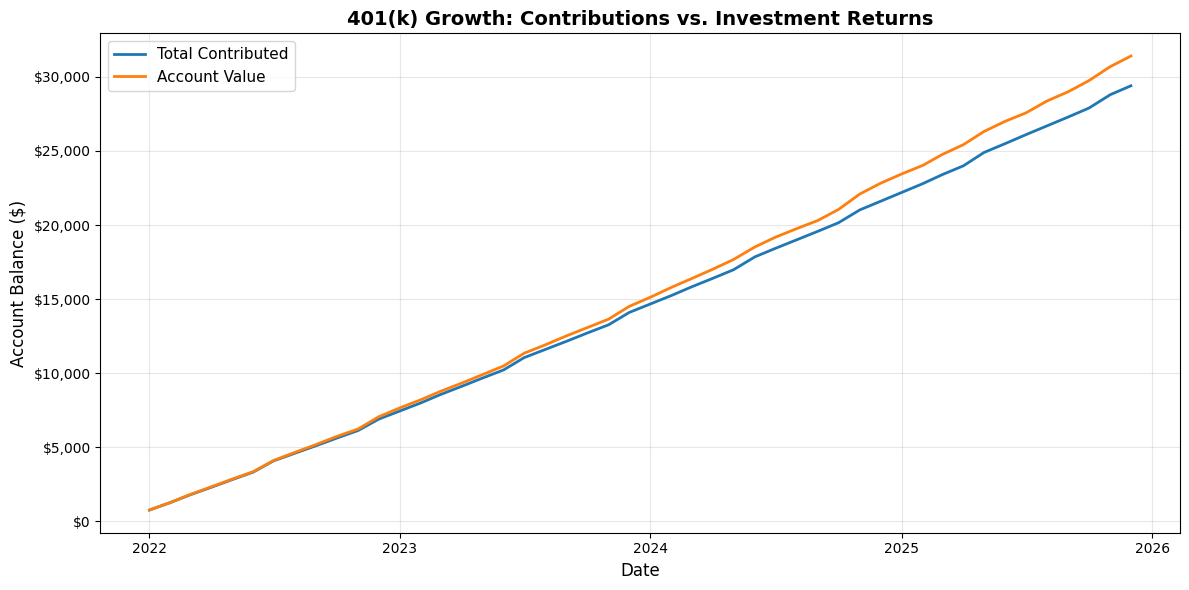

In [33]:
# Line chart: total contributed vs. account value over time
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(contributions['date'], contributions['total_contributed'], label='Total Contributed', linewidth=2)
ax.plot(contributions['date'], contributions['account_value'], label='Account Value', linewidth=2)

ax.set_title('401(k) Growth: Contributions vs. Investment Returns', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Account Balance ($)', fontsize=12)

# Dollar formatting on y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Format x-axis dates for readability
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation (2–3 sentences):** What do you notice about the gap between the two lines over time? How does this connect to the idea of starting to save for retirement early?

*Write here.*

Account value increased at a faster rate over time compared to the amount contributed. This shows the power of compound interest and the earlier you start investing the more likely you'll have greater results. 

---

## 6) Final Reflection

Answer the following questions. A few sentences each is fine.

1. **What was the most interesting thing you found in this dataset over the course of the semester?** It does not have to be from this notebook.

2. **Where did you use GitHub Copilot in this project?** What did it help with, and did you have to correct or verify anything it suggested?

3. **Looking at the full picture — income, spending, savings, credit cards, and retirement — how would you describe the financial health of this account holder?** Use at least two specific numbers from your analysis to support your answer.

**1. Most interesting finding this semester:**

*Write here.*

This may not be a typical answer, but I think in Week 13 finding only 5 fields that had missing values was very intersting. I find it impressive that is all the missing fields they had over the couple years. I would have assumed with all the effort it would take to enter this amount of data there would be way more missing values. 

**2. How I used GitHub Copilot:**

*Write here.*

To describe my use of Copilot for this assigment I need to take a step back and explain how I used it for most of the semester. Only the last two weeks since we had our check-up meeting have I used AI to help me write my code. Previously I did everything myself. I enjoy the process of writing it and looking back I'm still glad I did because it helped me really understand the concepts. After our meeting though I realized I need to use AI more as that's the way the world is going and I need experience using it. So as a result with this final project I used AI the most I have as almost all of my code was written using Copilot to assist me. I did have to correct a couple things, usually to do with variables. I felt like it also liked to add too many "print" commands which cluttered the output.

**3. Overall financial health assessment:**

*Write here.*

The first thing I thought to check when analyzing the financial health of this person is how their checking account balance looks. In section 2, account balances, they begin with a $500.00 balance. By the end when all the transactions have taken place they now have a balance of $396,138.08. This is excellent growth and shows that they have consistently saved more than they spent. Secondly, they are in good financial health in terms of saving for retirement. They’ve been saving for almost 4 years and have over $31k saved up already. Their non contribution growth is also already over $2k which shows compound interest is beginning to help grow the assets as well.  

---

## Submission

When you are finished:

1. Save your notebook
2. Restart the kernel and run all cells from top to bottom (**Kernel → Restart & Run All**) to confirm everything executes without errors
3. Push your completed notebook to your GitHub Classroom repository
4. Submit the repository link in Blackboard

Good work this semester!